# Quadrature Schemes in PySPIDER

Every library term in SPIDER is evaluated as a weighted-residual integral $\int_\Omega w(x) \, T(x) \, dx$ over each integration domain $\Omega$, where $w$ is a test function and $T$ is a library term. Numerically approximating that integral is the job of the *quadrature scheme*. By default PySPIDER uses the trapezoidal rule on the dataset's native uniform grid, but the framework also supports several more accurate or more flexible schemes, selected via two attributes on `SRDataset`:

```python
srd.integration_scheme = "trapezoidal"   # a string naming the scheme
srd.integration_options = {}             # a dict of scheme-specific options
```

This tutorial walks through all eight schemes currently available, shows how to configure each one (including the five newer additions: Simpson, Newton-Cotes/Boole, Gauss-Legendre, generalized moment-matching, and cubic-spline quadrature), and demonstrates plugging a couple of them into a full SPIDER pipeline. It assumes you've already gone through `01_Continuous.ipynb`.

| `integration_scheme` | What it does | Node requirement |
|---|---|---|
| `"trapezoidal"` (default) | Composite trapezoidal rule | Any uniform grid |
| `"simpson"` | Composite Simpson's rule (higher order) | Uniform grid |
| `"newton-cotes"` | Composite closed Newton-Cotes, default order 4 (Boole's rule) | Uniform grid |
| `"gauss-legendre"` | $N$-point Gauss-Legendre quadrature, exact to degree $2N-1$ | Data sampled exactly at the Gauss-Legendre nodes |
| `"clenshaw-curtis"` | DCT-based Clenshaw-Curtis quadrature | Data sampled on a full Chebyshev-Lobatto grid |
| `"truncated-cc-grid"` | Moment-matching on a (sub)grid of Chebyshev-Lobatto nodes | Chebyshev-Lobatto nodes (or an explicit subset) |
| `"moment-matching"` | Generalized moment-matching for **arbitrary/scattered** 1-D nodes | Any explicit node coordinates |
| `"cubic-spline"` | Fits and analytically integrates a cubic spline through the samples | Any node layout (uniform or not) |

The last two rows are the ones that most directly generalize PySPIDER to datasets that are *not* sampled on a nice uniform or Chebyshev grid.

### Imports

As in the other tutorials, we insert the local `src` directory at the front of the path so that Python finds this checkout of PySPIDER.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

In [2]:
from PySPIDER.commons.integration import int_arr
from PySPIDER.commons.quadrature_schemes import (
    mapped_chebyshev_nodes, truncated_chebyshev_nodes,
    newton_cotes_weights, gauss_legendre_nodes_and_weights, spline_quadrature_weights,
)

### Warm-up: calling `int_arr` directly

You don't need a full `SRDataset` to experiment with quadrature schemes: the dispatcher `PySPIDER.commons.integration.int_arr(arr, scheme=..., scheme_options=...)` operates on a plain numpy array. This is the same function `SRDataset.eval_on_domain` calls internally with `scheme=srd.integration_scheme` and `scheme_options=srd.integration_options`.

There's an important convention to be aware of: `"trapezoidal"`, `"simpson"`, and `"newton-cotes"` all treat consecutive array entries as **unit-spaced** (spacing $= 1$) and never look at `integration_options` for node positions - this mirrors how the rest of PySPIDER folds the true physical grid spacing $dx$ into the test-function weights (`Weight.dxs`) rather than into the quadrature step itself. If you use these three schemes standalone (as below), remember to rescale the raw result by your actual spacing (`dx` in 1-D, or the Jacobian $\prod_i dx_i$ in higher dimensions).

The remaining five schemes (`"clenshaw-curtis"`, `"truncated-cc-grid"`, `"gauss-legendre"`, `"moment-matching"`, `"cubic-spline"`) instead take the true sample coordinates and/or the true integration interval as explicit `scheme_options`, so their output is already a physical integral with no rescaling needed.

Let's compare all eight schemes against a reference computed with `scipy.integrate.quad`, integrating $g(x) = e^{-x}\cos(3x)$ over $[0, 2]$.

In [3]:
a, b = 0.0, 2.0
g = lambda x: np.exp(-x) * np.cos(3.0 * x)
ref, _ = quad(g, a, b)
print(f"Reference value (scipy.integrate.quad): {ref:.10f}")

Reference value (scipy.integrate.quad): 0.0756610756


In [4]:
def scheme_errors(N, seed=0):
    """Evaluate all 8 schemes with N samples and return their absolute errors vs. `ref`."""
    errors = {}

    # Uniform-grid schemes: unit-spacing convention, so rescale by dx afterwards.
    dx = (b - a) / (N - 1)
    x_uniform = np.linspace(a, b, N)
    fu = g(x_uniform)
    errors["trapezoidal"] = abs(int_arr(fu, scheme="trapezoidal") * dx - ref)
    errors["simpson"] = abs(int_arr(fu, scheme="simpson") * dx - ref)
    errors["newton-cotes"] = abs(int_arr(fu, scheme="newton-cotes") * dx - ref)

    # Node-prescribed schemes: pass the true interval, get a physical integral directly.
    x_gl, _ = gauss_legendre_nodes_and_weights(N, a, b)
    val_gl = int_arr(g(x_gl), scheme="gauss-legendre", scheme_options={"interval": (a, b)})
    errors["gauss-legendre"] = abs(val_gl - ref)

    x_cc = mapped_chebyshev_nodes(N - 1, a, b)
    val_cc = int_arr(g(x_cc), scheme="clenshaw-curtis", scheme_options={"interval": (a, b)})
    errors["clenshaw-curtis"] = abs(val_cc - ref)

    # NOTE: "truncated-cc-grid" is deliberately excluded here - unlike every other
    # scheme in this table, its `interval` option is always relative to the
    # canonical [-1, 1] reference grid rather than the true physical interval
    # (see the dedicated example below), so it can't share this [a, b] = [0, 2]
    # comparison on equal footing.

    # Arbitrary/scattered nodes: same random node set regardless of scheme.
    rng = np.random.default_rng(seed)
    x_scatter = np.sort(rng.uniform(a, b, N))
    val_mm = int_arr(
        g(x_scatter), scheme="moment-matching",
        scheme_options={"nodes": x_scatter, "interval": (a, b), "degree": 10},
    )
    errors["moment-matching"] = abs(val_mm - ref)

    val_sp = int_arr(
        g(x_scatter), scheme="cubic-spline",
        scheme_options={"nodes": x_scatter, "interval": (a, b)},
    )
    errors["cubic-spline"] = abs(val_sp - ref)

    return errors


schemes = [
    "trapezoidal", "simpson", "newton-cotes", "gauss-legendre",
    "clenshaw-curtis", "moment-matching", "cubic-spline",
]
Ns = [9, 17, 33]  # N - 1 divisible by 4 so Newton-Cotes/Boole panels tile evenly

header = "N".rjust(4) + "".join(s.rjust(18) for s in schemes)
print(header)
for N in Ns:
    errs = scheme_errors(N)
    print(str(N).rjust(4) + "".join(f"{errs[s]:.2e}".rjust(18) for s in schemes))

   N       trapezoidal           simpson      newton-cotes    gauss-legendre   clenshaw-curtis   moment-matching      cubic-spline
   9          5.25e-03          5.52e-04          1.77e-04          4.62e-13          5.64e-07          2.18e-04          3.65e-03
  17          1.29e-03          3.23e-05          2.35e-06          1.53e-16          1.33e-15          2.58e-07          3.97e-03
  33          3.21e-04          1.99e-06          3.52e-08          1.05e-15          1.11e-16          1.14e-07          7.15e-05


**A gotcha worth calling out:** `"truncated-cc-grid"` behaves differently from every other scheme above. Its `interval` option is always interpreted relative to the *canonical* $[-1, 1]$ reference Chebyshev-Lobatto grid, not the true physical domain - it's designed for the situation where your dataset already lives on a global Chebyshev grid spanning $[-1, 1]$ (with `num_intervals` reference intervals) and a given integration domain only covers *part* of it, e.g. $[-0.5, 0.8] \subset [-1, 1]$. (`"clenshaw-curtis"`, by contrast, affinely maps its full grid onto whatever `interval` you give it, so it works directly on any physical domain.) Here's a correct, standalone example:

In [5]:
# A sub-window [a_ref, b_ref] of the canonical [-1, 1] reference grid, NOT the
# [0, 2] physical domain used above.
a_ref, b_ref = -0.5, 0.8
ref_tcc, _ = quad(g, a_ref, b_ref)

for Nref in [32, 64, 128]:  # number of intervals in the *global* reference grid
    x_tcc = truncated_chebyshev_nodes(Nref, a_ref, b_ref)
    val_tcc = int_arr(
        g(x_tcc), scheme="truncated-cc-grid",
        scheme_options={"interval": (a_ref, b_ref), "num_intervals": Nref},
    )
    print(f"Nref={Nref:4d}  {len(x_tcc):3d} nodes fall in [{a_ref}, {b_ref}]  "
          f"error={abs(val_tcc - ref_tcc):.2e}")

Nref=  32   15 nodes fall in [-0.5, 0.8]  error=1.71e-12
Nref=  64   29 nodes fall in [-0.5, 0.8]  error=3.01e-10
Nref= 128   59 nodes fall in [-0.5, 0.8]  error=4.00e-12


All eight schemes converge as $N$ grows, but at very different rates: the fixed low order of the trapezoidal rule is visibly outpaced by the higher-order uniform-grid rules (Simpson, Newton-Cotes/Boole), while the polynomial-exact schemes for a smooth analytic $g$ (Gauss-Legendre, Clenshaw-Curtis, truncated-cc-grid) converge fastest of all. Let's visualize this with a convergence plot.

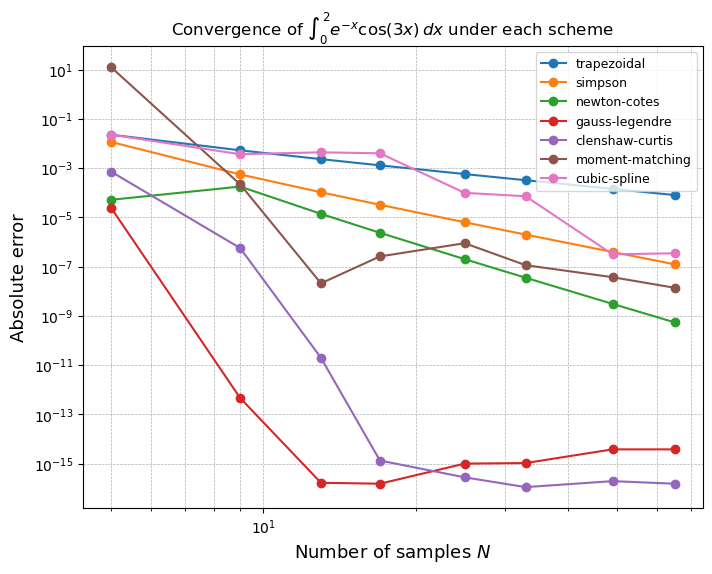

In [6]:
Ns_conv = [5, 9, 13, 17, 25, 33, 49, 65]  # N - 1 always divisible by 4
error_curves = {s: [] for s in schemes}
for N in Ns_conv:
    errs = scheme_errors(N)
    for s in schemes:
        error_curves[s].append(max(errs[s], 1e-16))  # floor for the log scale

plt.figure(figsize=(8, 6))
for s in schemes:
    plt.loglog(Ns_conv, error_curves[s], marker="o", label=s)
plt.xlabel("Number of samples $N$", fontsize=13)
plt.ylabel("Absolute error", fontsize=13)
plt.title(r"Convergence of $\int_0^2 e^{-x}\cos(3x)\,dx$ under each scheme")
plt.legend(fontsize=9)
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.show()

### Configuring each new scheme

Every scheme is selected the same way: set `srd.integration_scheme` to its name and `srd.integration_options` to a dict of the options below. Options that end in `_axes` (e.g. `simpson_axes`) list which array axes use the special scheme; every other axis silently falls back to trapezoidal, so you can mix schemes across an array's dimensions (e.g. Simpson in space, trapezoidal in time). Options like `interval`/`intervals` and `nodes` can be given either as a single value (applied to every selected axis) or as a per-axis list matching the number of dimensions.

The cell below builds the `integration_options` dict you'd assign to each scheme for the 1-D example above, so you can see exactly which keys each one expects.

In [7]:
N = 17
x_gl, _ = gauss_legendre_nodes_and_weights(N, a, b)
x_cc = mapped_chebyshev_nodes(N - 1, a, b)
rng = np.random.default_rng(0)
x_scatter = np.sort(rng.uniform(a, b, N))

example_options = {
    # Uniform-grid schemes: no scheme_options required at all (axis 0 by default).
    "simpson": {"simpson_axes": [0]},
    "newton-cotes": {"newton_cotes_axes": [0], "order": 4},  # order 4 = Boole's rule

    # Node-prescribed: data MUST already be sampled at these exact node positions.
    "gauss-legendre": {"gauss_axes": [0], "interval": (a, b)},
    "clenshaw-curtis": {"lobatto_axes": [0], "interval": (a, b)},
    # NOTE: unlike every other scheme here, truncated-cc-grid's "interval" is
    # relative to the canonical [-1, 1] reference grid, not the physical (a, b)
    # domain above - see the dedicated example a few cells up.
    "truncated-cc-grid": {"truncated_axes": [0], "interval": (-0.5, 0.8), "num_intervals": 64},

    # Arbitrary/scattered nodes: nodes are always required; interval is inferred
    # for cubic-spline but must be given explicitly for moment-matching.
    "moment-matching": {
        "moment_matching_axes": [0], "nodes": x_scatter, "interval": (a, b), "degree": 10,
    },
    "cubic-spline": {"spline_axes": [0], "nodes": x_scatter, "bc_type": "not-a-knot"},
}

for scheme, opts in example_options.items():
    print(f"{scheme!r}:")
    print(f"    srd.integration_options = {opts}")

'simpson':
    srd.integration_options = {'simpson_axes': [0]}
'newton-cotes':
    srd.integration_options = {'newton_cotes_axes': [0], 'order': 4}
'gauss-legendre':
    srd.integration_options = {'gauss_axes': [0], 'interval': (0.0, 2.0)}
'clenshaw-curtis':
    srd.integration_options = {'lobatto_axes': [0], 'interval': (0.0, 2.0)}
'truncated-cc-grid':
    srd.integration_options = {'truncated_axes': [0], 'interval': (-0.5, 0.8), 'num_intervals': 64}
'moment-matching':
    srd.integration_options = {'moment_matching_axes': [0], 'nodes': array([0.005477  , 0.03305527, 0.06717115, 0.08194705, 0.35131124,
       0.53957343, 1.08724998, 1.21327155, 1.27392337, 1.45899312,
       1.45931089, 1.62654048, 1.63170711, 1.71480855, 1.72635784,
       1.82551115, 1.87014485]), 'interval': (0.0, 2.0), 'degree': 10}
'cubic-spline':
    srd.integration_options = {'spline_axes': [0], 'nodes': array([0.005477  , 0.03305527, 0.06717115, 0.08194705, 0.35131124,
       0.53957343, 1.08724998, 1.21327155

A bit more detail on each:

- **`"simpson"`** - a drop-in, higher-order replacement for `"trapezoidal"`. Only needs `simpson_axes` (defaults to `[0]` if omitted); works for any axis length $\geq 3$.
- **`"newton-cotes"`** - a configurable-order generalization of Simpson (`order=2`) and the trapezoidal rule (`order=1`); `order=4`, the default, is Boole's rule. If `order` doesn't evenly tile the axis (e.g. a prime number of intervals), PySPIDER automatically falls back to the largest order that does, so this scheme never raises on an "awkward" axis length - it just quietly gets less accurate.
- **`"gauss-legendre"`** - the most accurate scheme per sample point (exact to degree $2N-1$ with only $N$ points), but the data must already live at the $N$-point Gauss-Legendre node positions for the chosen `interval`; PySPIDER validates this and raises a clear error if the supplied `nodes` don't match (see the next cell).
- **`"clenshaw-curtis"` / `"truncated-cc-grid"`** - the two pre-existing Chebyshev-based schemes; included here for completeness. Like Gauss-Legendre, they need data sampled at (a full or partial) Chebyshev-Lobatto grid.
- **`"moment-matching"`** - the most general scheme: give it the *true* coordinates of your samples (however irregular) and the *true* integration interval, and it solves a moment-matching least-squares system for the corresponding weights. Because it has to fit a global polynomial through every node, keep `degree` modest (well below `len(nodes) - 1`) for large, scattered node sets, or the weights can become ill-conditioned (try increasing `degree` above and watch the `moment-matching` column of the error table degrade past $N \approx 33$).
- **`"cubic-spline"`** - fits a local cubic spline (rather than one global polynomial) through the samples and integrates it exactly, so it stays well-conditioned even for large, scattered node sets. If `nodes` is omitted it defaults to a unit-spacing index grid, so it also works as a (less accurate but very general) drop-in for uniform data.

Since Gauss-Legendre validates the node positions, let's see what happens if you pass the wrong ones:

In [8]:
try:
    wrong_nodes = np.linspace(a, b, N)  # a uniform grid, NOT Gauss-Legendre nodes
    int_arr(
        g(wrong_nodes), scheme="gauss-legendre",
        scheme_options={"interval": (a, b), "nodes": wrong_nodes},
    )
except ValueError as exc:
    print(f"ValueError: {exc}")

ValueError: Axis 0: 'gauss-legendre' requires the 17-point Gauss-Legendre node set on [0.0, 2.0] (ascending or descending). Resample the data at these nodes, or use 'moment-matching' for arbitrary/scattered node sets.


### Plugging a scheme into a full SPIDER pipeline

`SRDataset.make_domains` always slices integration domains out of your dataset's native array using integer grid indices (see `get_slice`/`IntegrationDomain` in `commons/process_library_terms.py`), so the samples handed to `int_arr` are always on your dataset's original **uniform** grid. That has a direct consequence for which schemes are true "drop-in" replacements versus which need extra setup:

- `"simpson"` and `"newton-cotes"` need nothing beyond a uniform grid, so you can switch to them with a one-line change, exactly like `"trapezoidal"`.
- `"gauss-legendre"`, `"clenshaw-curtis"`, and `"truncated-cc-grid"` need samples at specific non-uniform node positions. Using them for real end-to-end runs means *generating or resampling your dataset* at those nodes ahead of time along the relevant axis (this is how the two pre-existing Chebyshev schemes have always been used in PySPIDER) - they are not drop-ins for data produced by `make_domains` on a uniform grid.
- `"moment-matching"` and `"cubic-spline"` are the schemes to reach for when your *raw dataset itself* is irregularly sampled (e.g. scattered sensor timestamps or particle positions): you'd construct your own domains/coordinate arrays from the true sample locations rather than going through `make_domains`, then pass those coordinates as `nodes`.

Below, we reuse the small Taylor-Green vortex setup from `01_Continuous.ipynb` (shrunk for speed) and rebuild the same library matrix three times, switching only `integration_scheme`, to show that Simpson and Newton-Cotes really are one-line swaps.

In [9]:
from PySPIDER.commons.library import Observable
from PySPIDER.continuous.process_library_terms import SRDataset
from PySPIDER.commons.z3base import FullRank

# A smaller Taylor-Green vortex than 01_Continuous.ipynb, just for speed here.
Lx = 4; Ly = 4; Lt = 1
Nx = 64; Ny = Nx; Nt = 32
dx = Lx / Nx; dy = Ly / Ny; dt = Lt / Nt

x = np.arange(0, Lx, dx); y = np.arange(0, Ly, dy); t = np.arange(0, Lt, dt)
xg, yg = np.meshgrid(x, y)
U = 4 * np.einsum('i,j,k->ijk', np.sin(4 * x), np.cos(4 * y), np.exp(-0.64 * t))
V = -4 * np.einsum('i,j,k->ijk', np.cos(4 * x), np.sin(4 * y), np.exp(-0.64 * t))
P = 4 * np.einsum('ij, k->ijk', np.cos(8 * xg) + np.cos(8 * yg), np.exp(-1.28 * t))
u = np.concatenate([U[:, :, :, np.newaxis], V[:, :, :, np.newaxis]], axis=3)

pobs = Observable(string='p', rank=0)
uobs = Observable(string='u', rank=1)
observables = [uobs, pobs]
data_dict = {'p': P, 'u': u}
world_size = np.array(P.shape)
dxs = [dx, dy, dt]

In [10]:
Q_by_scheme = {}
for scheme in ["trapezoidal", "simpson", "newton-cotes"]:
    np.random.seed(1)  # keep the sampled domains identical across schemes
    srd = SRDataset(
        world_size=world_size, data_dict=data_dict, observables=observables, dxs=dxs,
        irreps=(FullRank(rank=0),), cache_primes=True,
    )
    srd.integration_scheme = scheme  # <-- the only line that changes between runs!

    srd.make_libraries(max_complexity=3, max_dt=1, max_dx=2)
    srd.make_domains(ndomains=5, domain_size=[10, 10, 8], pad=0)
    srd.make_weights(m=8, qmax=0)
    srd.set_LT_scale(L=1, T=1)
    srd.make_library_matrices(debug=False, parallel=False)

    Q_by_scheme[scheme] = srd.libs[FullRank(rank=0)].Q

terms = srd.libs[FullRank(rank=0)].terms
print(f"Library matrix shape: {Q_by_scheme['trapezoidal'].shape} "
      f"({len(terms)} terms x {Q_by_scheme['trapezoidal'].shape[0]} (weight, domain) rows)")
print(f"Terms: {terms}")

Library matrix shape: (5, 13) (13 terms x 5 (weight, domain) rows)
Terms: [p, p · p, p · p · p, p · ∂t p, p · u_α · u_α, p · ∂α u_α, ∂α p · u_α, ∂α² p, ∂t p, u_α · u_α, u_α · ∂t u_α, ∂α u_α, ∂t ∂α u_α]


In [11]:
Q_trap = Q_by_scheme["trapezoidal"]
for scheme in ["simpson", "newton-cotes"]:
    # A Frobenius-norm relative difference is much better-behaved here than an
    # elementwise one: several entries of Q_trap are numerically close to zero
    # (terms that vanish for this analytic solution), which would otherwise
    # make an elementwise relative difference blow up without indicating any
    # real problem.
    rel_diff = np.linalg.norm(Q_by_scheme[scheme] - Q_trap) / np.linalg.norm(Q_trap)
    print(f"{scheme:>13} vs trapezoidal: relative difference (Frobenius norm) = {rel_diff:.2%}")

      simpson vs trapezoidal: relative difference (Frobenius norm) = 4.55%
 newton-cotes vs trapezoidal: relative difference (Frobenius norm) = 31.75%


The library matrices differ from `trapezoidal` by a few percent, reflecting the fact that our domains are quite small (`domain_size=[10, 10, 8]`, chosen for a fast-running tutorial) - on such short axes, `newton_cotes_panel_order` often has to fall back from the requested `order=4` to a lower order that evenly tiles the axis (e.g. order 3 on the 10-point spatial axes, order 1 on the 8-point time axis), so part of what you're seeing above is that fallback rather than a full Boole's-rule upgrade. With larger, better-resolved domains (more grid points per domain), `order=4` would tile more axes evenly and both `simpson` and `newton-cotes` would converge more closely toward each other and away from `trapezoidal`, at a higher accuracy for the same domain size.

### Cheat sheet

| Scheme | Order of accuracy | Data requirement | Best for |
|---|---|---|---|
| `trapezoidal` | 2nd order | Uniform grid | Quick default; always works |
| `simpson` | 4th order | Uniform grid, any length $\geq 3$ | Smooth data on a uniform grid, one-line upgrade from trapezoidal |
| `newton-cotes` | Up to 6th order (configurable) | Uniform grid | Smooth data where you want to tune the accuracy/order tradeoff |
| `gauss-legendre` | Exact to degree $2N-1$ | Data at $N$-point Gauss-Legendre nodes | Highest accuracy per sample when you control where samples are taken |
| `clenshaw-curtis` | Spectral for smooth $f$ | Full Chebyshev-Lobatto grid | Synthetic/generated data you can sample on a Chebyshev grid |
| `truncated-cc-grid` | Spectral-ish, subgrid | (Sub)set of Chebyshev-Lobatto nodes | Same as above, but only part of the domain is available |
| `moment-matching` | Exact up to `degree` | Any explicit node coordinates | Arbitrarily/irregularly spaced 1-D data; keep `degree` modest for large scattered sets |
| `cubic-spline` | Locally cubic (well-conditioned) | Any node layout | Large scattered/irregular datasets where `moment-matching`'s global polynomial fit becomes ill-conditioned |

In short: stick with `trapezoidal`/`simpson`/`newton-cotes` for ordinary uniformly-gridded data, reach for `gauss-legendre`/`clenshaw-curtis`/`truncated-cc-grid` when you can generate data at their special node sets, and use `moment-matching` or `cubic-spline` as soon as your data is genuinely sampled at arbitrary or scattered points.